# 20 — Best-Tour Visualization (Optional)

**Maps to:** `report/Chapters/Task4.tex` §`T4:TourViz`.  
**Ticket:** TICKET-20.

Plot the best tour found across all experiments, overlaid on kroA100 city
coordinates. Also plot the known optimal tour for comparison if available.

---
## Setup

In [1]:
%run ./15_experiment_runner.ipynb

Loaded kroA100: 100 cities


Best fitness : 89127.80
Known optimal: 21,282
Gap          : 318.8%
Wall time    : 0.2s

Per-generation log (first 5 rows):
Saved: ../results/649a28b7_seed0042.csv
Size : 11,878 bytes
Shape: (101, 16)
Cols : ['generation', 'best_fitness', 'mean_fitness', 'diversity', 'pop_size', 'n_generations', 'crossover_rate', 'mutation_rate', 'tournament_k', 'elitism_count', 'selection_method', 'crossover_method', 'mutation_method', 'repair_enabled', 'repair_strategy', 'seed']
Grid: 6 configurations
  976d5e2d | xover=pmx seed=1
  976d5e2d | xover=pmx seed=2
  976d5e2d | xover=pmx seed=3
  0fc01629 | xover=ox seed=1
  0fc01629 | xover=ox seed=2
  0fc01629 | xover=ox seed=3
Total: 6 | Completed: 6 | Pending: 0
Nothing to run — all results already exist.
Re-running the same grid (all should be skipped):
Total: 6 | Completed: 6 | Pending: 0
Nothing to run — all results already exist.


In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.constrained_layout.use": True,
})

FIGURES_DIR = Path("../results/figures")
OPTIMAL = 21282  # kroA100 known optimal (TSPLIB)

---
## Load Benchmark and Find Best Tour

Scan all sweep result CSVs to find the run with the lowest best fitness,
then re-run that single configuration to recover the actual tour array.

In [3]:
coords, dist_matrix = load_tsp(Path("../data/TSP-dataset/kroA100.tsp"))
n_cities = dist_matrix.shape[0]

sweep_summary = pd.read_csv(Path("../results/sweep_summary.csv"))
best_row = sweep_summary.sort_values("min").iloc[0]

print("Best single run found in sweep:")
print(f"  pop_size       : {int(best_row['pop_size'])}")
print(f"  crossover_rate : {best_row['crossover_rate']}")
print(f"  mutation_rate  : {best_row['mutation_rate']}")
print(f"  selection      : {best_row['selection_method']}")
print(f"  best fitness   : {best_row['min']:.2f}")
print(f"  gap to optimal : {(best_row['min'] - OPTIMAL) / OPTIMAL * 100:.1f}%")

Best single run found in sweep:
  pop_size       : 200
  crossover_rate : 0.95
  mutation_rate  : 0.1
  selection      : tournament
  best fitness   : 42622.53
  gap to optimal : 100.3%


In [4]:
import glob

best_fitness = float("inf")
best_tour = None
best_seed = None

SWEEP_BASE = {
    "n_generations": 500,
    "tournament_k": 3,
    "elitism_count": 2,
    "crossover_method": "naive",
    "mutation_method": "swap",
    "repair_enabled": True,
    "repair_strategy": "random",
}

best_config_params = {
    "pop_size": int(best_row["pop_size"]),
    "crossover_rate": best_row["crossover_rate"],
    "mutation_rate": best_row["mutation_rate"],
    "selection_method": best_row["selection_method"],
}

for seed in range(1, 31):
    cfg = ExperimentConfig(**{**SWEEP_BASE, **best_config_params, "seed": seed})
    result = run_experiment(cfg, dist_matrix)
    if result["best_fitness"] < best_fitness:
        best_fitness = result["best_fitness"]
        best_tour = result["best_tour"]
        best_seed = seed

print(f"Best tour: seed={best_seed}, fitness={best_fitness:.2f}")
print(f"Tour valid: {is_valid_permutation(best_tour, n_cities)}")

Best tour: seed=16, fitness=42622.53
Tour valid: True


---
## Plot: Best Tour Found

City coordinates with tour edges overlaid. Start city highlighted.

Saved: ../results/figures/best_tour.pdf


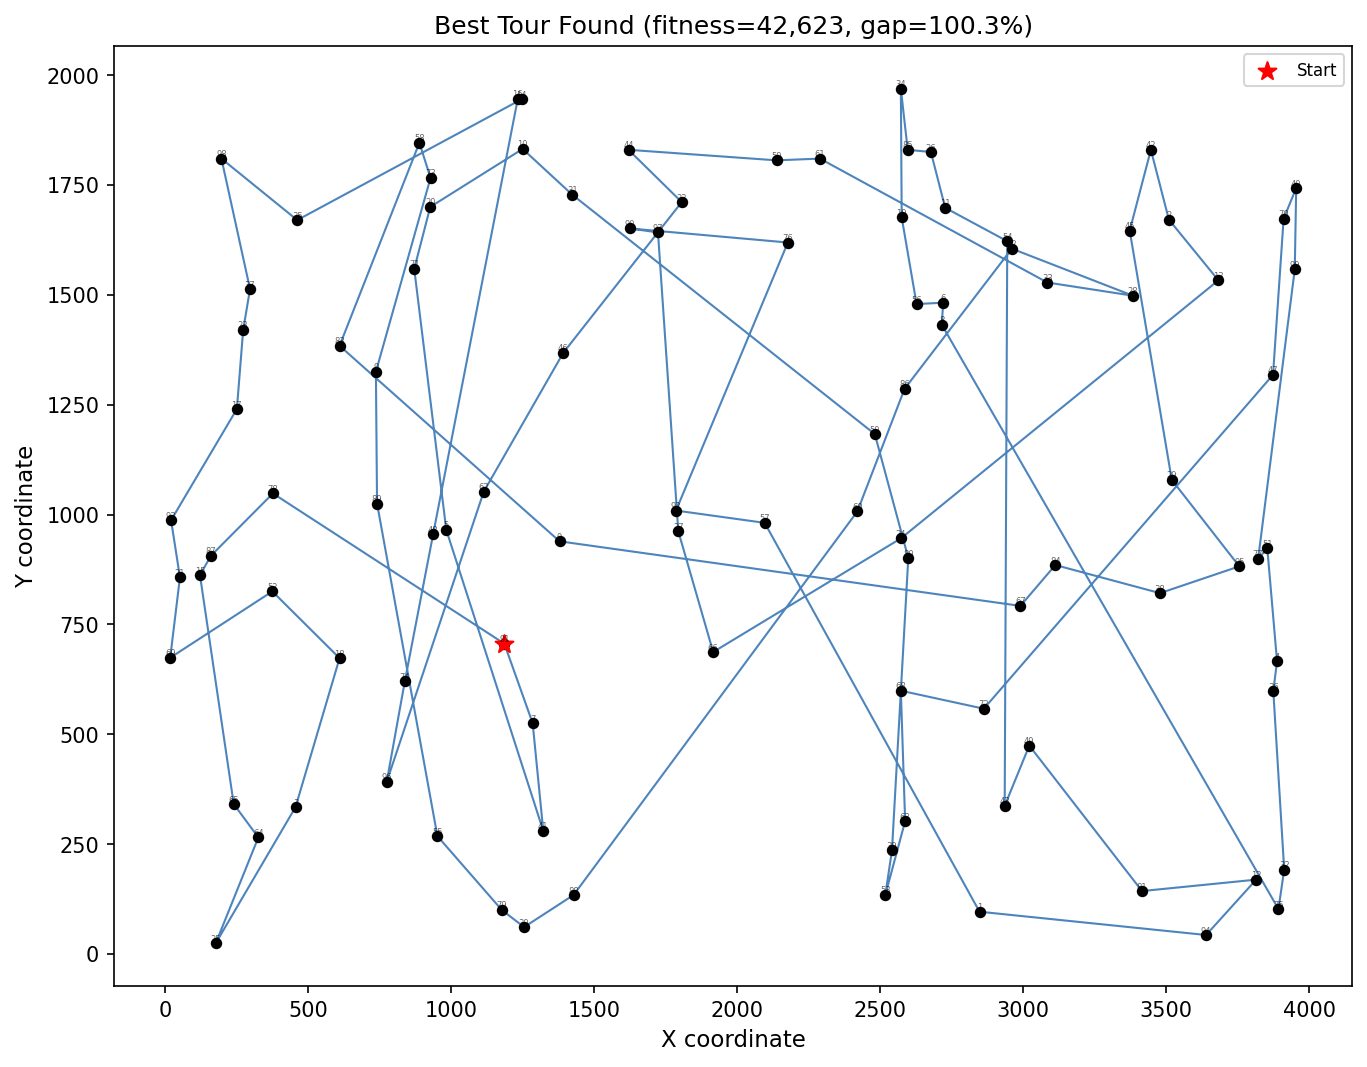

In [5]:
def plot_tour(ax, coords, tour, title, color="#2166ac", alpha=0.8):
    tour_closed = np.append(tour, tour[0])
    xs = coords[tour_closed, 0]
    ys = coords[tour_closed, 1]

    ax.plot(xs, ys, "-", color=color, linewidth=1.0, alpha=alpha, zorder=1)
    ax.scatter(coords[:, 0], coords[:, 1], s=20, color="black", zorder=2)
    ax.scatter(coords[tour[0], 0], coords[tour[0], 1], s=80, color="red",
               marker="*", zorder=3, label="Start")

    for i in range(n_cities):
        ax.annotate(str(i), (coords[i, 0], coords[i, 1]),
                    fontsize=4, ha="center", va="bottom", alpha=0.6)

    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_title(title)
    ax.legend(fontsize=8)

fig, ax = plt.subplots(figsize=(9, 7))
plot_tour(ax, coords, best_tour,
          f"Best Tour Found (fitness={best_fitness:,.0f}, gap={((best_fitness - OPTIMAL) / OPTIMAL * 100):.1f}%)")

path = FIGURES_DIR / "best_tour.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Plot: Cities Only (No Tour)

Reference plot showing the city layout without any tour edges.

Saved: ../results/figures/kroA100_cities.pdf


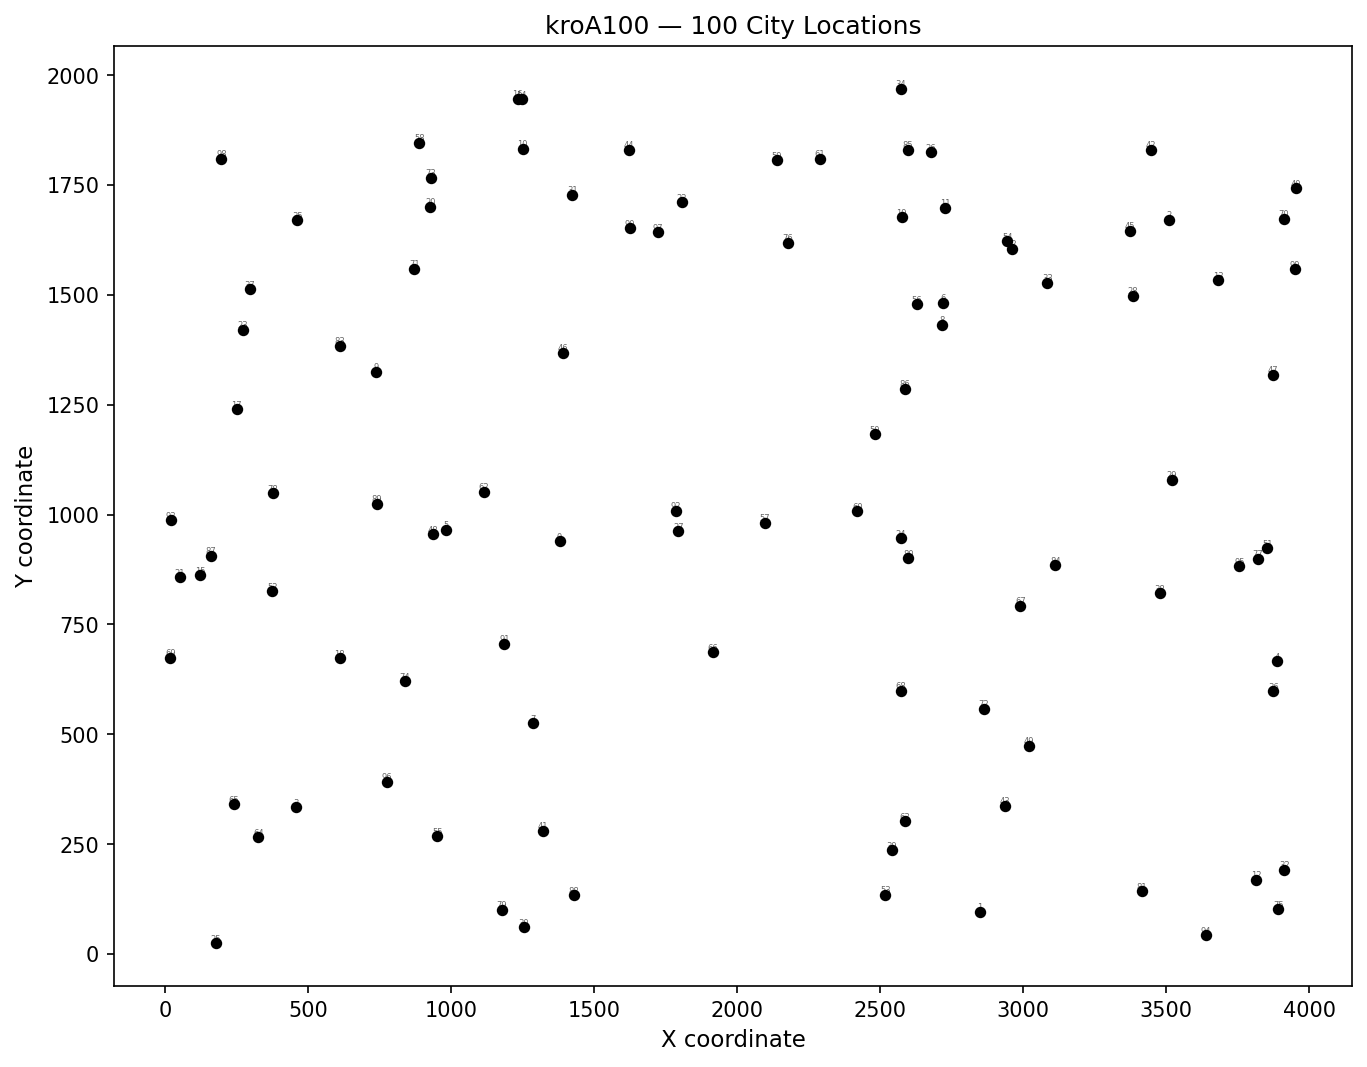

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(coords[:, 0], coords[:, 1], s=20, color="black", zorder=2)
for i in range(n_cities):
    ax.annotate(str(i), (coords[i, 0], coords[i, 1]),
                fontsize=4, ha="center", va="bottom", alpha=0.6)
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.set_title("kroA100 — 100 City Locations")

path = FIGURES_DIR / "kroA100_cities.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Summary

This notebook produces two figures:

1. **Best tour found** — the shortest valid tour discovered across all 30
   seeds of the sweep's best configuration (naive crossover with repair).
   Tour edges overlaid on kroA100 city coordinates with city labels and
   start marker.
2. **City locations** — reference plot of the 100 city positions without
   tour edges.

Both figures saved to `results/figures/` at 300 DPI in PDF format.